In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

dataset = "mnli"
seed = 2026
selected_dp_percent = [i for i in range(1, 101)]
iteration = 500


def plot_data_selection(seed, dataset, train_data, g, iteration=500):
    """Plot 9-subplot data-selection figure for one (dataset, train_data) setting.

    Looks up the following variables from g (caller's globals()):
      - seed{seed}_{dataset}_{train_data}_inv_lam1e_6
      - seed{seed}_{dataset}_{train_data}_r{R}_eigen1e_2_inv1e_6     (R in ranks)
      - seed{seed}_{dataset}_{train_data}_r{R}_eigen1e_2_eigen1e_2   (R in ranks)
      - seed{seed}_{dataset}_{train_data}_A_BASE
      - seed{seed}_{dataset}_{train_data}_inv_early_stop
      - seed{seed}_{dataset}_{train_data}_topr_early_stop
      - selected_dp_percent  (shared)
    """
    selected_dp_percent = g["selected_dp_percent"]
    inv             = g[f"seed{seed}_{dataset}_{train_data}_inv_lam1e_6"]
    A_BASE          = g[f"seed{seed}_{dataset}_{train_data}_A_BASE"]
    inv_early_stop  = g[f"seed{seed}_{dataset}_{train_data}_inv_early_stop"]
    topr_early_stop = g[f"seed{seed}_{dataset}_{train_data}_topr_early_stop"]

    ranks = [1, 5, 10, 15, 20, 25, 30]
    eigen_data_1 = [(g[f"seed{seed}_{dataset}_{train_data}_r{r}_eigen1e_2_eigen1e_2"], f"rank {r}%") for r in ranks]
    eigen_data_2 = [(g[f"seed{seed}_{dataset}_{train_data}_r{r}_eigen1e_2_inv1e_6"],   f"rank {r}%") for r in ranks]
    diff_data    = [(np.array(d1) - np.array(d2), lab)
                    for (d1, lab), (d2, _) in zip(eigen_data_1, eigen_data_2)]

    num_dp = train_data
    ZOOM_PCT = 20
    ZOOM_N = ZOOM_PCT

    fig, axes = plt.subplots(3, 3, figsize=(30, 28))
    axes = axes.flatten()

    inv_color = "red"
    eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

    # ===== Subplot (1,1): Eigen mode (shapley + prediction) - 1~ZOOM_PCT% =====
    ax1 = axes[0]
    plot_percent_10 = selected_dp_percent[:ZOOM_N]
    ax1.plot(plot_percent_10, inv[:ZOOM_N], color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=10, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_1):
        ax1.plot(plot_percent_10, data[:ZOOM_N], color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="s", markersize=10, label=label, alpha=0.85)

    all_data_10_eigen = [inv[:ZOOM_N]] + [d[0][:ZOOM_N] for d in eigen_data_1]
    y_min_10 = min(min(d) for d in all_data_10_eigen)
    y_max_10 = max(max(d) for d in all_data_10_eigen)
    y_margin_10 = (y_max_10 - y_min_10) * 0.1
    ylim_10_min = y_min_10 - y_margin_10
    ylim_10_max = y_max_10 + y_margin_10

    ax1.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax1.set_ylabel("Accuracy", fontsize=20)
    ax1.set_title(f"Eigen Shapley + Eigen Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax1.legend(fontsize=20, loc="best")
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax1.set_ylim(ylim_10_min, ylim_10_max)
    ax1.tick_params(axis="both", labelsize=18)

    # ===== Subplot (1,2): Eigen shapley + INV prediction - 1~ZOOM_PCT% =====
    ax2 = axes[1]
    ax2.plot(plot_percent_10, inv[:ZOOM_N], color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=10, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_2):
        ax2.plot(plot_percent_10, data[:ZOOM_N], color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="^", markersize=10, label=label, alpha=0.85)

    all_data_10_inv = [inv[:ZOOM_N]] + [d[0][:ZOOM_N] for d in eigen_data_2]
    y_min_10_inv = min(min(d) for d in all_data_10_inv)
    y_max_10_inv = max(max(d) for d in all_data_10_inv)
    ylim_10_min = min(ylim_10_min, y_min_10_inv - (y_max_10_inv - y_min_10_inv) * 0.1)
    ylim_10_max = max(ylim_10_max, y_max_10_inv + (y_max_10_inv - y_min_10_inv) * 0.1)

    ax2.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax2.set_ylabel("Accuracy", fontsize=20)
    ax2.set_title(f"Eigen Shapley + INV Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax2.legend(fontsize=20, loc="best")
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax2.set_ylim(ylim_10_min, ylim_10_max)
    ax2.tick_params(axis="both", labelsize=18)

    ax1.set_ylim(ylim_10_min, ylim_10_max)

    # ===== Subplot (1,3): Difference (Eigen - INV) - 1~100% =====
    ax3 = axes[2]
    for i, (data, label) in enumerate(diff_data):
        ax3.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="d", markersize=6, label=label, alpha=0.85)

    all_diff_data = [d[0] for d in diff_data]
    y_min_diff = min(min(d) for d in all_diff_data)
    y_max_diff = max(max(d) for d in all_diff_data)
    y_margin_diff = max(abs(y_min_diff), abs(y_max_diff)) * 0.1
    ylim_diff_min = y_min_diff - y_margin_diff
    ylim_diff_max = y_max_diff + y_margin_diff

    ax3.axhline(y=0, color="black", linestyle="--", linewidth=1.5, alpha=0.5)
    ax3.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax3.set_ylabel("Accuracy Difference", fontsize=20)
    ax3.set_title(f"Difference (Eigen Pred - INV Pred) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax3.legend(fontsize=20, loc="best")
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(0, 101)
    ax3.set_ylim(ylim_diff_min, ylim_diff_max)
    ax3.tick_params(axis="both", labelsize=18)

    # ===== Subplot (2,1): Eigen mode (shapley + prediction) - 1~100% =====
    ax4 = axes[3]
    ax4.plot(selected_dp_percent, inv, color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=6, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_1):
        ax4.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="s", markersize=6, label=label, alpha=0.85)

    all_data_100_eigen = [inv] + [d[0] for d in eigen_data_1]
    y_min_100 = min(min(d) for d in all_data_100_eigen)
    y_max_100 = max(max(d) for d in all_data_100_eigen)
    y_margin_100 = (y_max_100 - y_min_100) * 0.1
    ylim_100_min = y_min_100 - y_margin_100
    ylim_100_max = y_max_100 + y_margin_100

    ax4.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax4.set_ylabel("Accuracy", fontsize=20)
    ax4.set_title(f"Eigen Shapley + Eigen Pred (1-100%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax4.legend(fontsize=20, loc="best")
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim(0, 101)
    ax4.set_ylim(ylim_100_min, ylim_100_max)
    ax4.tick_params(axis="both", labelsize=18)

    # ===== Subplot (2,2): Eigen shapley + INV prediction - 1~100% =====
    ax5 = axes[4]
    ax5.plot(selected_dp_percent, inv, color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=6, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_2):
        ax5.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="^", markersize=6, label=label, alpha=0.85)

    all_data_100_inv = [inv] + [d[0] for d in eigen_data_2]
    y_min_100_inv = min(min(d) for d in all_data_100_inv)
    y_max_100_inv = max(max(d) for d in all_data_100_inv)
    ylim_100_min = min(ylim_100_min, y_min_100_inv - (y_max_100_inv - y_min_100_inv) * 0.1)
    ylim_100_max = max(ylim_100_max, y_max_100_inv + (y_max_100_inv - y_min_100_inv) * 0.1)

    ax5.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax5.set_ylabel("Accuracy", fontsize=20)
    ax5.set_title(f"Eigen Shapley + INV Pred (1-100%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax5.legend(fontsize=20, loc="best")
    ax5.grid(True, alpha=0.3)
    ax5.set_xlim(0, 101)
    ax5.set_ylim(ylim_100_min, ylim_100_max)
    ax5.tick_params(axis="both", labelsize=18)

    ax4.set_ylim(ylim_100_min, ylim_100_max)

    # ===== Subplot (2,3): Early Stop Ratio =====
    ax6 = axes[5]
    method_names = ["INV"] + [f"rank {r}%" for r in ranks]
    method_values = [inv_early_stop[0]] + list(topr_early_stop)
    bar_colors = [inv_color] + list(eigen_colors)
    x_pos = np.arange(len(method_names))
    bars = ax6.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor="black", linewidth=1.2)
    for bar, value in zip(bars, method_values):
        ax6.text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
                 f"{value:.2f}", ha="center", va="bottom", fontsize=20, fontweight="bold")
    ax6.set_xlabel("Method", fontsize=20)
    ax6.set_ylabel("Early Stop Ratio (%)", fontsize=20)
    ax6.set_title(f"Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(method_names, fontsize=20)
    ax6.grid(True, alpha=0.3, axis="y")
    ax6.tick_params(axis="y", labelsize=18)

    # ===== Subplot (3,1): ER for Eigen Pred - 1~ZOOM_PCT% =====
    ax7 = axes[6]
    inv_zoom_arr = np.array(inv[:ZOOM_N])

    er_data_eigen = []
    for i, (data, label) in enumerate(eigen_data_1):
        ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
        er_data_eigen.append((ers, f"{label} ({np.mean(ers):.3f}±{np.std(ers):.3f})"))

    for i, (ers, label) in enumerate(er_data_eigen):
        ax7.plot(plot_percent_10, ers, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="s", markersize=10, label=label, alpha=0.85)
    ax7.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5, alpha=0.5, label="y=1 (baseline)")
    ax7.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax7.set_ylabel("Excess Retention (ER)", fontsize=20)
    ax7.set_title(f"ER: Eigen Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax7.legend(fontsize=20, loc="best")
    ax7.grid(True, alpha=0.3)
    ax7.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax7.tick_params(axis="both", labelsize=18)

    # ===== Subplot (3,2): ER for INV Pred - 1~ZOOM_PCT% =====
    ax8 = axes[7]
    er_data_inv = []
    for i, (data, label) in enumerate(eigen_data_2):
        ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
        er_data_inv.append((ers, f"{label} ({np.mean(ers):.3f}±{np.std(ers):.3f})"))

    for i, (ers, label) in enumerate(er_data_inv):
        ax8.plot(plot_percent_10, ers, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="^", markersize=10, label=label, alpha=0.85)
    ax8.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5, alpha=0.5, label="y=1 (baseline)")
    ax8.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax8.set_ylabel("Excess Retention (ER)", fontsize=20)
    ax8.set_title(f"ER: INV Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax8.legend(fontsize=20, loc="best")
    ax8.grid(True, alpha=0.3)
    ax8.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax8.tick_params(axis="both", labelsize=18)

    # ===== Subplot (3,3): Turn off =====
    axes[8].axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:

# ===== Configuration =====
num_dp = 1000
# =========================

seed2026_mnli_1000_A_BASE = 

seed2026_mnli_1000_inv_lam1e_6           = 
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2026_mnli_1000_r1_eigen1e_2_inv1e_6  = 
seed2026_mnli_1000_r5_eigen1e_2_inv1e_6  = 
seed2026_mnli_1000_r10_eigen1e_2_inv1e_6 = 
seed2026_mnli_1000_r15_eigen1e_2_inv1e_6 = 
seed2026_mnli_1000_r20_eigen1e_2_inv1e_6 = 
seed2026_mnli_1000_r25_eigen1e_2_inv1e_6 = 
seed2026_mnli_1000_r30_eigen1e_2_inv1e_6 = 

# Prediction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2026_mnli_1000_r1_eigen1e_2_eigen1e_2  = 
seed2026_mnli_1000_r5_eigen1e_2_eigen1e_2  = 
seed2026_mnli_1000_r10_eigen1e_2_eigen1e_2 = 
seed2026_mnli_1000_r15_eigen1e_2_eigen1e_2 = 
seed2026_mnli_1000_r20_eigen1e_2_eigen1e_2 = 
seed2026_mnli_1000_r25_eigen1e_2_eigen1e_2 = 
seed2026_mnli_1000_r30_eigen1e_2_eigen1e_2 = 

seed2026_mnli_1000_inv_early_stop  = []
seed2026_mnli_1000_topr_early_stop = []

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
# =========================

seed2026_mnli_2000_A_BASE = 

seed2026_mnli_2000_inv_lam1e_6           = 
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2026_mnli_2000_r1_eigen1e_2_inv1e_6  = 
seed2026_mnli_2000_r5_eigen1e_2_inv1e_6  = 
seed2026_mnli_2000_r10_eigen1e_2_inv1e_6 = 
seed2026_mnli_2000_r15_eigen1e_2_inv1e_6 = 
seed2026_mnli_2000_r20_eigen1e_2_inv1e_6 = 
seed2026_mnli_2000_r25_eigen1e_2_inv1e_6 = 
seed2026_mnli_2000_r30_eigen1e_2_inv1e_6 = 

# Prediction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2026_mnli_2000_r1_eigen1e_2_eigen1e_2  = 
seed2026_mnli_2000_r5_eigen1e_2_eigen1e_2  = 
seed2026_mnli_2000_r10_eigen1e_2_eigen1e_2 = 
seed2026_mnli_2000_r15_eigen1e_2_eigen1e_2 = 
seed2026_mnli_2000_r20_eigen1e_2_eigen1e_2 = 
seed2026_mnli_2000_r25_eigen1e_2_eigen1e_2 = 
seed2026_mnli_2000_r30_eigen1e_2_eigen1e_2 = 

seed2026_mnli_2000_inv_early_stop  = []
seed2026_mnli_2000_topr_early_stop = []

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)


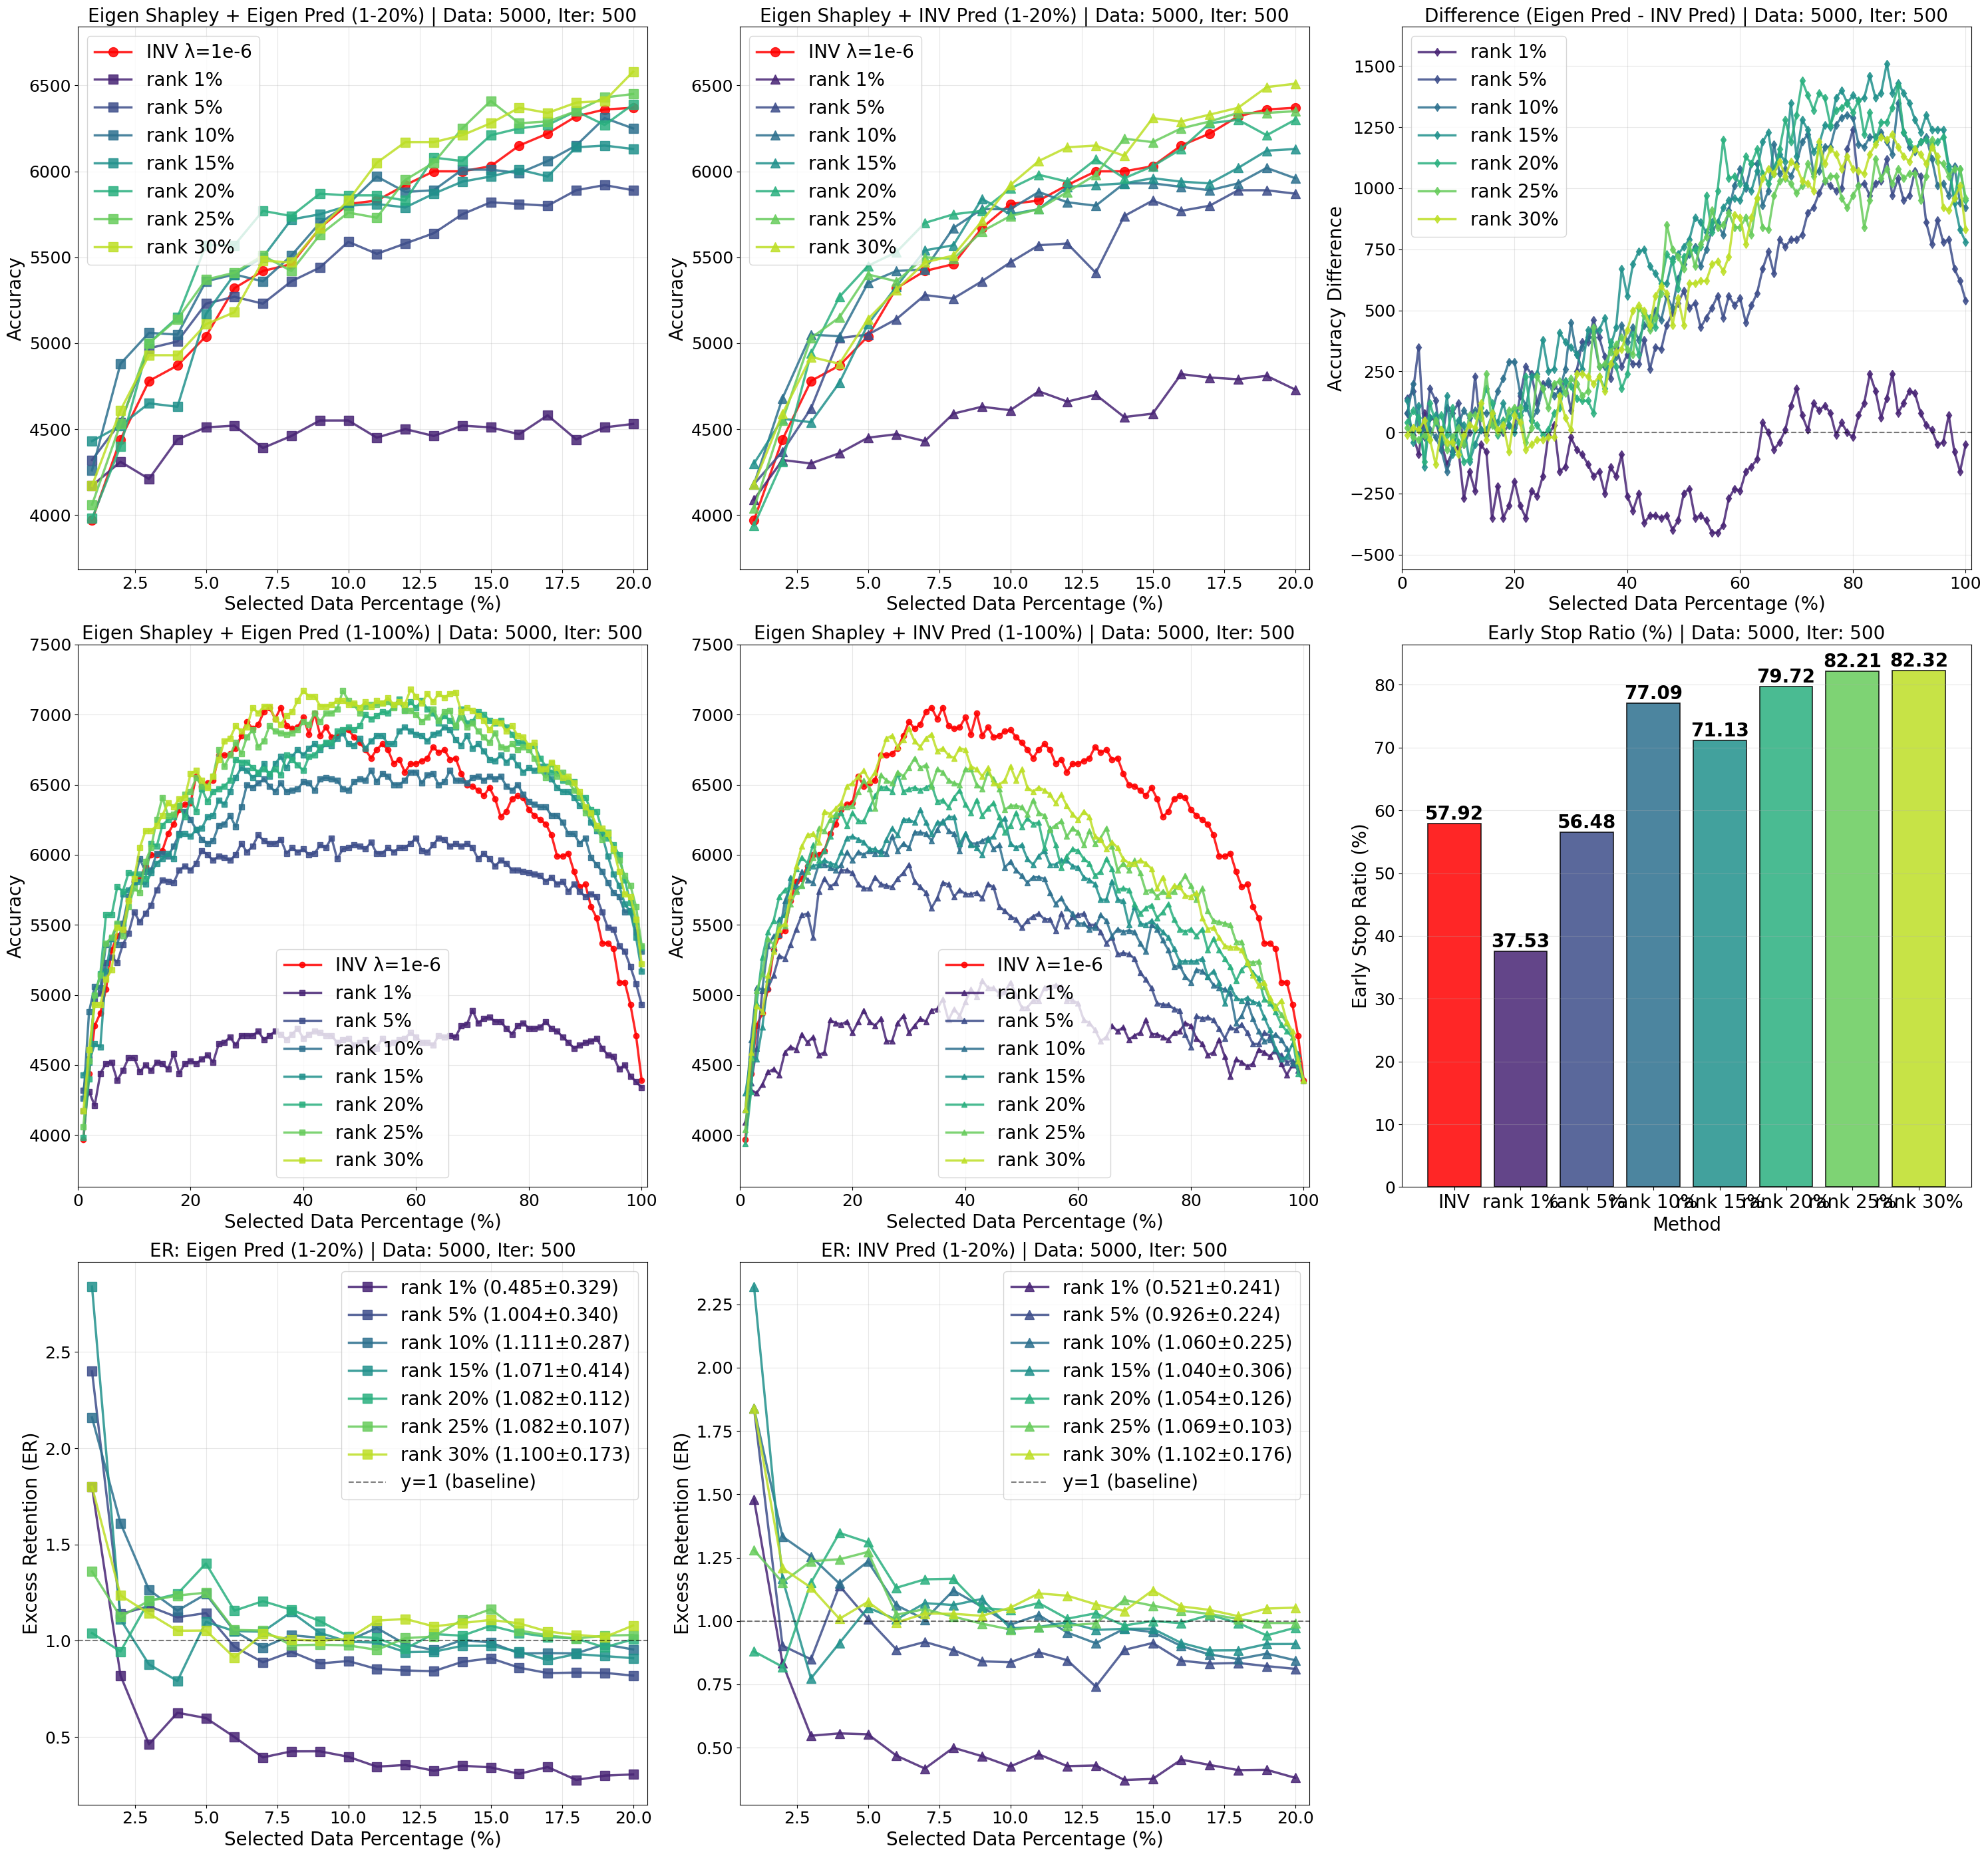

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
# =========================

seed2026_mnli_5000_A_BASE = 3720

seed2026_mnli_5000_inv_lam1e_6           = [3970, 4440, 4780, 4870, 5040, 5320, 5420, 5460, 5670, 5810, 5830, 5920, 6000, 6000, 6030, 6150, 6220, 6320, 6360, 6370, 6560, 6490, 6510, 6530, 6710, 6710, 6720, 6760, 6850, 6950, 6900, 6930, 7020, 7050, 6970, 7050, 6920, 6900, 6910, 6980, 6860, 7010, 6850, 6910, 6840, 6850, 6880, 6890, 6840, 6800, 6750, 6690, 6750, 6790, 6750, 6650, 6680, 6590, 6650, 6650, 6670, 6690, 6770, 6730, 6750, 6680, 6690, 6580, 6500, 6490, 6460, 6420, 6480, 6400, 6270, 6310, 6400, 6420, 6410, 6320, 6280, 6250, 6220, 6140, 5990, 5990, 6010, 5880, 5770, 5790, 5630, 5550, 5370, 5370, 5330, 5090, 5090, 4930, 4710, 4390]
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2026_mnli_5000_r1_eigen1e_2_inv1e_6  = [4090, 4320, 4300, 4360, 4450, 4470, 4430, 4590, 4630, 4610, 4720, 4660, 4700, 4570, 4590, 4820, 4800, 4790, 4810, 4730, 4810, 4890, 4810, 4780, 4830, 4670, 4670, 4800, 4850, 4730, 4780, 4830, 4810, 4890, 4900, 4970, 4820, 4900, 4850, 4950, 5040, 4990, 5100, 5050, 5050, 5010, 5020, 5090, 5000, 4910, 4910, 4960, 4960, 5050, 5060, 5070, 5060, 4960, 4960, 4940, 4820, 4800, 4750, 4670, 4700, 4780, 4740, 4770, 4680, 4710, 4730, 4820, 4720, 4720, 4700, 4680, 4730, 4740, 4800, 4780, 4690, 4650, 4570, 4590, 4680, 4560, 4420, 4540, 4520, 4490, 4510, 4610, 4590, 4560, 4610, 4510, 4430, 4500, 4540, 4390]
seed2026_mnli_5000_r5_eigen1e_2_inv1e_6  = [4180, 4370, 4620, 5030, 5050, 5140, 5280, 5260, 5360, 5470, 5570, 5580, 5410, 5740, 5830, 5770, 5800, 5890, 5890, 5870, 5790, 5760, 5760, 5840, 5790, 5780, 5770, 5830, 5870, 5930, 5810, 5770, 5730, 5620, 5690, 5800, 5790, 5700, 5750, 5720, 5720, 5730, 5690, 5790, 5770, 5630, 5600, 5560, 5540, 5480, 5530, 5560, 5580, 5540, 5540, 5460, 5580, 5490, 5560, 5570, 5580, 5500, 5500, 5450, 5370, 5410, 5290, 5300, 5290, 5260, 5160, 5110, 5050, 4940, 4930, 4930, 4900, 4890, 4720, 4630, 4850, 4830, 4840, 4820, 4760, 4690, 4770, 4750, 4790, 4730, 4650, 4650, 4730, 4710, 4600, 4570, 4520, 4530, 4460, 4390]
seed2026_mnli_5000_r10_eigen1e_2_inv1e_6 = [4180, 4680, 5050, 5040, 5350, 5420, 5430, 5670, 5780, 5780, 5880, 5820, 5800, 5930, 5930, 5910, 5890, 5930, 6020, 5960, 6020, 6000, 6030, 6010, 6030, 6010, 6130, 6030, 6080, 6050, 6160, 6160, 6150, 6100, 6180, 6240, 6170, 6150, 6030, 6150, 6080, 6080, 6100, 6120, 6040, 6070, 5910, 5950, 5890, 5850, 5800, 5840, 5840, 5830, 5730, 5650, 5690, 5620, 5580, 5510, 5510, 5470, 5480, 5570, 5530, 5420, 5470, 5450, 5460, 5450, 5370, 5310, 5500, 5470, 5390, 5320, 5200, 5210, 5130, 5090, 5180, 5170, 5130, 5070, 5050, 5040, 5010, 4800, 4850, 4950, 4830, 4740, 4670, 4680, 4720, 4680, 4620, 4510, 4510, 4390]
seed2026_mnli_5000_r15_eigen1e_2_inv1e_6 = [4300, 4560, 4540, 4770, 5110, 5330, 5540, 5570, 5840, 5750, 5780, 5910, 5920, 5930, 5960, 5940, 5930, 6020, 6120, 6130, 6110, 6090, 6040, 6040, 6010, 6110, 6190, 6140, 6250, 6250, 6230, 6320, 6230, 6150, 6230, 6230, 6270, 6270, 6080, 6150, 6070, 6050, 6000, 6110, 6130, 6220, 6260, 6080, 6050, 6070, 5970, 5930, 5990, 6030, 5930, 5930, 5960, 5960, 5920, 5910, 5840, 5820, 5790, 5680, 5680, 5810, 5680, 5670, 5500, 5630, 5510, 5500, 5530, 5490, 5450, 5410, 5330, 5240, 5240, 5240, 5240, 5260, 5130, 5170, 5090, 4940, 5060, 4980, 4960, 4980, 4950, 4940, 4840, 4750, 4620, 4540, 4560, 4650, 4580, 4390]
seed2026_mnli_5000_r20_eigen1e_2_inv1e_6 = [3940, 4310, 4940, 5270, 5450, 5530, 5700, 5750, 5770, 5900, 5980, 5940, 6070, 5960, 6030, 6130, 6280, 6300, 6210, 6300, 6240, 6240, 6330, 6420, 6480, 6480, 6450, 6580, 6450, 6470, 6480, 6460, 6480, 6500, 6380, 6390, 6340, 6410, 6460, 6360, 6300, 6390, 6280, 6330, 6370, 6270, 6160, 6210, 6300, 6200, 6260, 6220, 6230, 6050, 6190, 6070, 5910, 5990, 6040, 6030, 5970, 5940, 5850, 5880, 5970, 5900, 5750, 5760, 5750, 5650, 5580, 5620, 5640, 5550, 5590, 5650, 5540, 5470, 5450, 5470, 5420, 5470, 5320, 5400, 5320, 5260, 5200, 5100, 5180, 5220, 5160, 5120, 4970, 4940, 4880, 4790, 4740, 4700, 4440, 4390]
seed2026_mnli_5000_r25_eigen1e_2_inv1e_6 = [4040, 4550, 5030, 5150, 5400, 5360, 5500, 5490, 5650, 5740, 5780, 5880, 5980, 6190, 6170, 6250, 6290, 6340, 6340, 6350, 6450, 6530, 6470, 6330, 6570, 6530, 6510, 6590, 6560, 6620, 6690, 6620, 6640, 6490, 6610, 6590, 6530, 6510, 6500, 6610, 6610, 6500, 6470, 6590, 6540, 6470, 6320, 6350, 6350, 6340, 6290, 6390, 6300, 6280, 6180, 6210, 6240, 6130, 6190, 6160, 6070, 6170, 6080, 6120, 6190, 6060, 5890, 5940, 5890, 5960, 5870, 5740, 5750, 5700, 5740, 5710, 5740, 5790, 5850, 5780, 5680, 5760, 5600, 5530, 5520, 5510, 5500, 5380, 5380, 5240, 5230, 5240, 5060, 4960, 4920, 4860, 4800, 4700, 4550, 4390]
seed2026_mnli_5000_r30_eigen1e_2_inv1e_6 = [4180, 4590, 4920, 4880, 5140, 5310, 5470, 5510, 5710, 5920, 6060, 6140, 6150, 6090, 6310, 6290, 6330, 6370, 6490, 6510, 6560, 6600, 6530, 6590, 6710, 6830, 6850, 6770, 6820, 6900, 6810, 6770, 6830, 6860, 6740, 6760, 6710, 6690, 6760, 6750, 6630, 6610, 6560, 6620, 6510, 6500, 6530, 6630, 6530, 6610, 6480, 6450, 6480, 6460, 6430, 6370, 6430, 6350, 6290, 6250, 6310, 6270, 6130, 6110, 6040, 6090, 6050, 5970, 5940, 5940, 5960, 5940, 5900, 5760, 5840, 5720, 5780, 5770, 5710, 5700, 5730, 5550, 5470, 5480, 5410, 5350, 5340, 5340, 5320, 5230, 5140, 5070, 5090, 4980, 4910, 4960, 4810, 4740, 4530, 4390]

# Predction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2026_mnli_5000_r1_eigen1e_2_eigen1e_2  = [4170, 4310, 4210, 4440, 4510, 4520, 4390, 4460, 4550, 4550, 4450, 4500, 4460, 4520, 4510, 4470, 4580, 4440, 4510, 4530, 4510, 4540, 4570, 4520, 4650, 4660, 4700, 4640, 4710, 4710, 4710, 4740, 4680, 4710, 4740, 4720, 4680, 4720, 4760, 4690, 4720, 4740, 4730, 4710, 4710, 4660, 4680, 4690, 4640, 4660, 4680, 4610, 4620, 4690, 4650, 4660, 4680, 4690, 4730, 4700, 4660, 4660, 4640, 4710, 4700, 4710, 4700, 4780, 4790, 4890, 4800, 4830, 4840, 4810, 4810, 4760, 4720, 4780, 4800, 4760, 4760, 4770, 4810, 4760, 4740, 4700, 4660, 4620, 4640, 4660, 4670, 4690, 4620, 4570, 4560, 4470, 4500, 4420, 4380, 4340]
seed2026_mnli_5000_r5_eigen1e_2_eigen1e_2  = [4320, 4540, 4970, 5010, 5230, 5270, 5230, 5360, 5440, 5590, 5520, 5580, 5640, 5750, 5820, 5810, 5800, 5890, 5920, 5890, 5940, 6030, 6000, 5960, 5990, 5980, 5960, 6000, 6080, 6020, 6060, 6140, 6100, 6080, 6080, 6110, 6010, 6050, 6020, 6040, 6000, 6010, 6070, 6050, 6120, 5970, 6040, 6050, 6070, 6060, 6040, 6090, 6010, 6010, 6050, 6020, 6050, 6050, 6080, 6120, 6030, 6020, 6070, 6120, 6110, 6060, 6080, 6060, 6080, 6050, 5970, 6010, 5970, 5920, 5960, 5940, 5890, 5890, 5880, 5870, 5860, 5850, 5810, 5840, 5790, 5810, 5740, 5790, 5740, 5700, 5720, 5700, 5590, 5480, 5470, 5350, 5310, 5200, 5080, 4930]
seed2026_mnli_5000_r10_eigen1e_2_eigen1e_2 = [4260, 4880, 5060, 5050, 5360, 5400, 5360, 5510, 5700, 5810, 5970, 5880, 5890, 6010, 6010, 5990, 6060, 6150, 6310, 6250, 6180, 6110, 6080, 6100, 6210, 6220, 6280, 6200, 6340, 6500, 6480, 6510, 6540, 6490, 6450, 6510, 6450, 6460, 6470, 6520, 6510, 6460, 6540, 6550, 6540, 6530, 6470, 6460, 6520, 6540, 6530, 6600, 6520, 6580, 6560, 6500, 6500, 6530, 6590, 6590, 6510, 6570, 6580, 6500, 6520, 6600, 6530, 6530, 6510, 6550, 6560, 6530, 6560, 6540, 6560, 6490, 6460, 6500, 6430, 6380, 6360, 6340, 6340, 6280, 6280, 6230, 6150, 6150, 6080, 6120, 5980, 5930, 5880, 5800, 5730, 5700, 5590, 5600, 5450, 5310]
seed2026_mnli_5000_r15_eigen1e_2_eigen1e_2 = [4430, 4520, 4650, 4630, 5170, 5400, 5500, 5720, 5750, 5800, 5810, 5790, 5870, 5940, 5970, 6010, 5970, 6140, 6150, 6130, 6180, 6190, 6270, 6280, 6390, 6360, 6450, 6550, 6620, 6600, 6550, 6580, 6650, 6560, 6650, 6700, 6620, 6700, 6750, 6710, 6760, 6790, 6750, 6790, 6780, 6830, 6870, 6790, 6780, 6830, 6760, 6810, 6850, 6850, 6790, 6790, 6880, 6910, 6880, 6860, 6850, 6810, 6860, 6870, 6910, 6890, 6820, 6780, 6850, 6760, 6790, 6740, 6680, 6670, 6710, 6660, 6700, 6640, 6590, 6620, 6600, 6630, 6590, 6540, 6480, 6450, 6450, 6410, 6350, 6330, 6230, 6170, 6140, 5990, 5860, 5780, 5650, 5590, 5410, 5170]
seed2026_mnli_5000_r20_eigen1e_2_eigen1e_2 = [3980, 4400, 5000, 5150, 5570, 5570, 5770, 5740, 5870, 5860, 5860, 5830, 6080, 6060, 6210, 6250, 6270, 6350, 6270, 6390, 6310, 6470, 6380, 6450, 6470, 6490, 6530, 6680, 6660, 6660, 6620, 6590, 6610, 6580, 6610, 6570, 6710, 6680, 6640, 6600, 6700, 6710, 6770, 6800, 6800, 6880, 6890, 6910, 6890, 6920, 7000, 6970, 6990, 7020, 7010, 7060, 7110, 7030, 7090, 7050, 7100, 7040, 7010, 6940, 6990, 6960, 6910, 7040, 6940, 6950, 7020, 7000, 6960, 6940, 6960, 6910, 6860, 6800, 6800, 6780, 6780, 6690, 6630, 6590, 6590, 6530, 6530, 6520, 6410, 6410, 6320, 6310, 6170, 6120, 6070, 6000, 5820, 5660, 5520, 5340]
seed2026_mnli_5000_r25_eigen1e_2_eigen1e_2 = [4060, 4530, 5000, 5140, 5370, 5410, 5510, 5420, 5630, 5760, 5730, 5950, 6050, 6250, 6410, 6280, 6290, 6350, 6430, 6450, 6550, 6490, 6490, 6560, 6750, 6630, 6710, 6800, 6720, 6840, 6890, 6770, 6810, 6920, 6880, 6870, 6860, 6870, 6890, 6950, 6930, 7010, 6950, 7010, 7010, 7040, 7170, 7100, 7070, 7010, 7060, 7070, 7070, 7080, 7090, 7050, 7090, 7030, 7030, 7000, 6950, 6980, 7040, 6960, 7020, 7030, 6920, 6980, 6910, 6940, 6880, 6840, 6800, 6870, 6770, 6760, 6790, 6750, 6770, 6750, 6690, 6600, 6550, 6650, 6560, 6590, 6520, 6460, 6420, 6300, 6290, 6190, 6110, 6160, 6030, 5960, 5850, 5780, 5630, 5350]
seed2026_mnli_5000_r30_eigen1e_2_eigen1e_2 = [4170, 4610, 4930, 4930, 5110, 5180, 5480, 5470, 5670, 5830, 6050, 6170, 6170, 6210, 6280, 6370, 6340, 6400, 6410, 6580, 6600, 6530, 6480, 6560, 6680, 6810, 6830, 6920, 6880, 6910, 7050, 7010, 7060, 7060, 6970, 6930, 6990, 7020, 7100, 7170, 7130, 7130, 7060, 7060, 7070, 7100, 7100, 7070, 7080, 7050, 7090, 7060, 7100, 7080, 7120, 7070, 7090, 7070, 7180, 7130, 7080, 7150, 7090, 7150, 7120, 7150, 7160, 7020, 7050, 7030, 6990, 6960, 6890, 6950, 6940, 6880, 6920, 6850, 6840, 6780, 6800, 6610, 6610, 6660, 6620, 6550, 6560, 6510, 6450, 6340, 6300, 6210, 6190, 6150, 6040, 5880, 5720, 5700, 5540, 5220]

seed2026_mnli_5000_inv_early_stop  = [57.92]
seed2026_mnli_5000_topr_early_stop = [37.53, 56.48, 77.09, 71.13, 79.72, 82.21, 82.32]

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 10000
# =========================

seed2026_mnli_10000_A_BASE = 

seed2026_mnli_10000_inv_lam1e_6           = 
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2026_mnli_10000_r1_eigen1e_2_inv1e_6  = 
seed2026_mnli_10000_r5_eigen1e_2_inv1e_6  = 
seed2026_mnli_10000_r10_eigen1e_2_inv1e_6 = 
seed2026_mnli_10000_r15_eigen1e_2_inv1e_6 = 
seed2026_mnli_10000_r20_eigen1e_2_inv1e_6 = 
seed2026_mnli_10000_r25_eigen1e_2_inv1e_6 = 
seed2026_mnli_10000_r30_eigen1e_2_inv1e_6 = 

# Predction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2026_mnli_10000_r1_eigen1e_2_eigen1e_2  = 
seed2026_mnli_10000_r5_eigen1e_2_eigen1e_2  = 
seed2026_mnli_10000_r10_eigen1e_2_eigen1e_2 = 
seed2026_mnli_10000_r15_eigen1e_2_eigen1e_2 = 
seed2026_mnli_10000_r20_eigen1e_2_eigen1e_2 = 
seed2026_mnli_10000_r25_eigen1e_2_eigen1e_2 = 
seed2026_mnli_10000_r30_eigen1e_2_eigen1e_2 = 

seed2026_mnli_10000_inv_early_stop  = []
seed2026_mnli_10000_topr_early_stop = []

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)
